In [1]:
from fastai import *
from fastai.vision.widgets import *
from icrawler.builtin import BingImageCrawler

**Data Gathering**

In [2]:
crawler = BingImageCrawler(storage={'root_dir' : 'dataset/bear/grizzly_bear'})
crawler.crawl(keyword='grizzly bear', max_num=50)
crawler = BingImageCrawler(storage={'root_dir' : 'dataset/bear/black_bear'})
crawler.crawl(keyword='black bear', max_num=50)

2026-08-29 22:14:55,489 - INFO - icrawler.crawler - start crawling...
2026-08-29 22:14:55,490 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-08-29 22:14:55,491 - INFO - feeder - thread feeder-001 exit
2026-08-29 22:14:55,493 - INFO - icrawler.crawler - starting 1 parser threads...
2026-08-29 22:14:55,569 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-08-29 22:14:56,305 - INFO - parser - parsing result page https://www.bing.com/images/async?q=grizzly bear&first=0
2026-08-29 22:14:56,370 - INFO - downloader - skip downloading file 000001.jpg
2026-08-29 22:14:56,372 - INFO - downloader - skip downloading file 000002.jpg
2026-08-29 22:14:56,373 - INFO - downloader - skip downloading file 000003.jpg
2026-08-29 22:14:56,394 - INFO - downloader - skip downloading file 000004.jpg
2026-08-29 22:14:56,395 - INFO - downloader - skip downloading file 000005.jpg
2026-08-29 22:14:56,395 - INFO - downloader - skip downloading file 000006.jpg
2026-08-29 22:14:56,397 -

In [3]:
from pathlib import Path
from fastai.vision.all import get_image_files, verify_images

path = Path("dataset/bear")
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)

[]

In [4]:
from fastai.vision.all import *

bears = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128)
)

**Data cleaning**

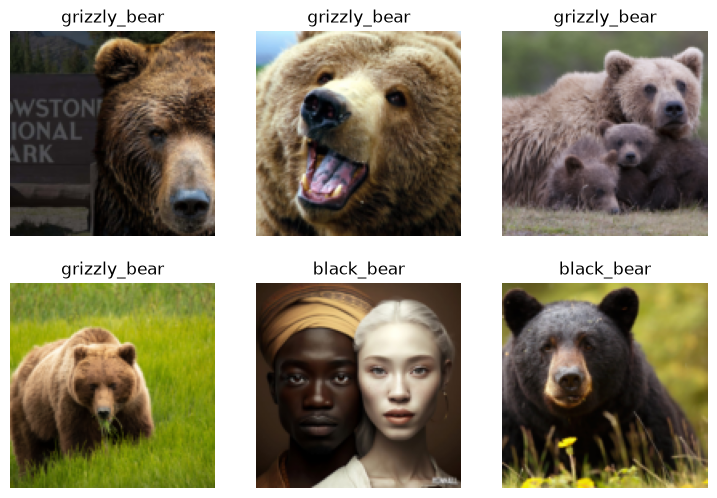

In [5]:
path = 'dataset/bear'
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n = 6)

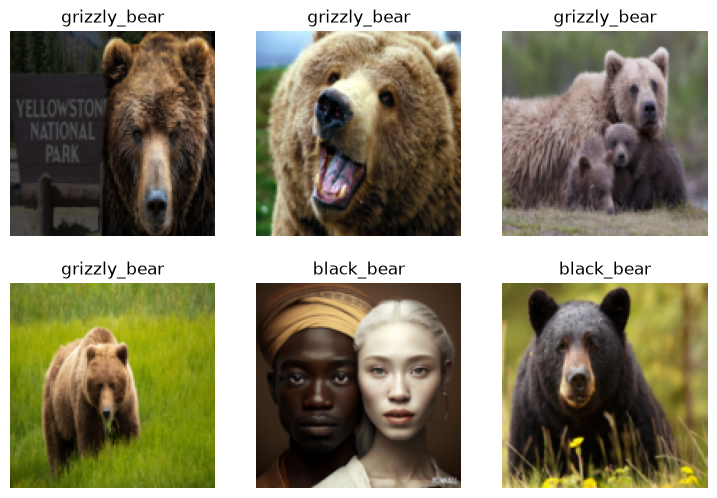

In [6]:
bears = bears.new(item_tfms=Resize(128, method='squish'))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=6)

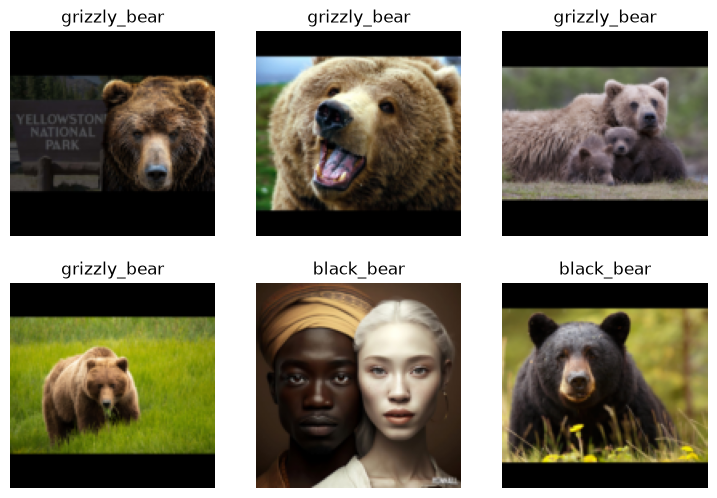

In [7]:
bears = bears.new(item_tfms=Resize(128, method='pad', pad_mode='zeros'))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=6)

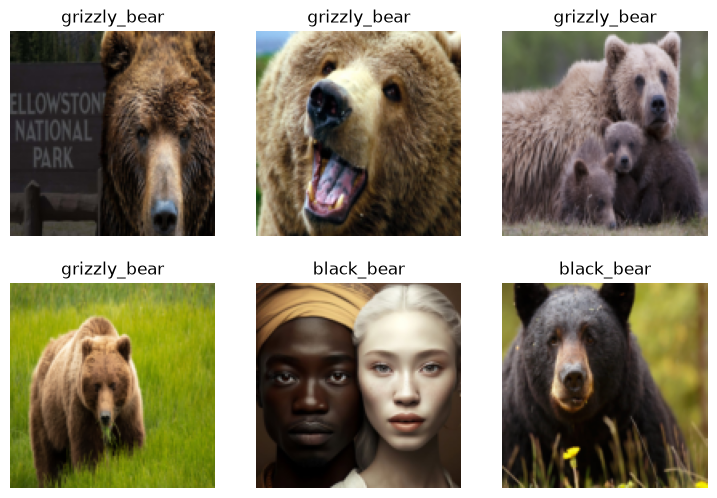

In [8]:
bears = bears.new(item_tfms=RandomResizedCrop(128, min_scale=0.3))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=6)

**Data augmentation**

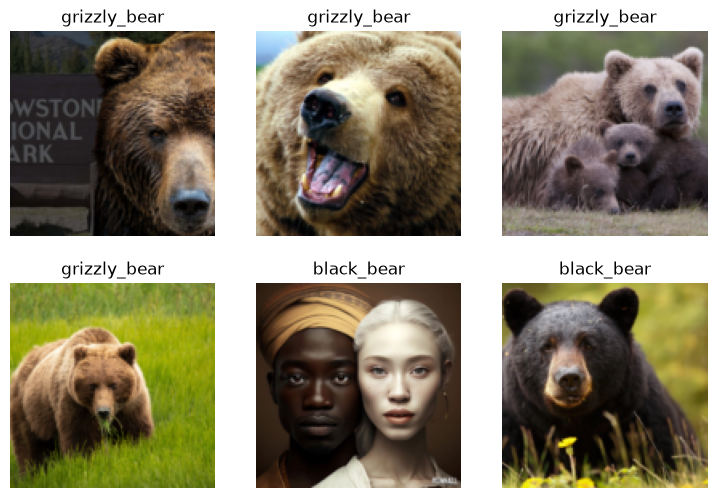

In [9]:
bears = bears.new(item_tfms=Resize(128), batch_tfms=aug_transforms(mult=2))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=6)

**Training the model and using model to clean data**

In [10]:
bears = bears.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms()
)
dls = bears.dataloaders(path)

In [11]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,nan,0.912232,0.166667,00:03


d:\Engineering\Technology\AI\FastAI\.venv\Lib\site-packages\fastprogress\fastprogress.py:93: UserWarning: Your generator is empty.
  warn("Your generator is empty.")


epoch,train_loss,valid_loss,error_rate,time
0,nan,0.912232,0.166667,00:02
1,nan,0.912232,0.166667,00:02
2,nan,0.912232,0.166667,00:03
3,nan,0.912232,0.166667,00:02


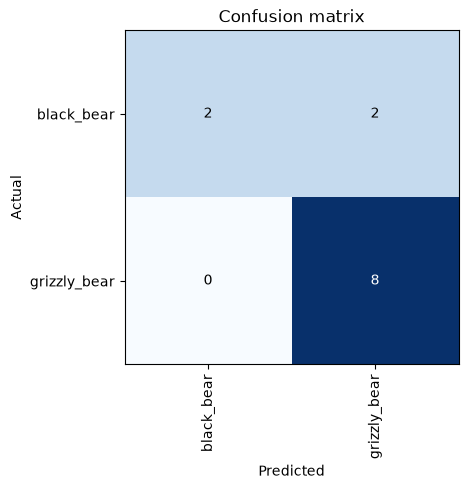

In [12]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

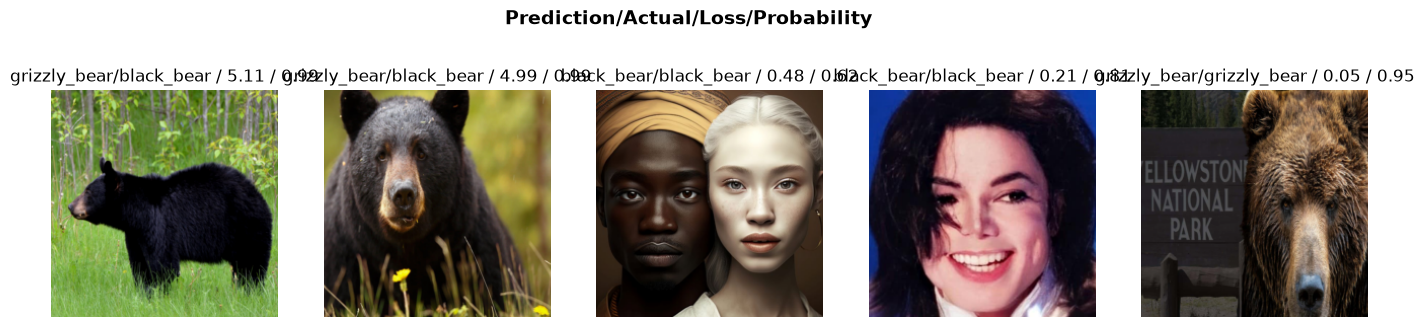

In [13]:
interp.plot_top_losses(5, nrows=1, figsize=(17,4))

In [ ]:
cleaner = ImageClassifierCleaner(learn)
cleaner

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>